In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [17]:
import os
import shutil
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# --- 1. CONFIGURATION & DIRECTORIES ---
DATASET_DIR = '/kaggle/input/cervical-cancer-largest-dataset-sipakmed'
WORKING_DIR = '/kaggle/working'
TRAIN_DIR = os.path.join(WORKING_DIR, 'train')
VAL_DIR = os.path.join(WORKING_DIR, 'val')
TEST_DIR = os.path.join(WORKING_DIR, 'test')

IMG_SIZE = 224
BATCH_SIZE = 32

# Clean and recreate directories to ensure fresh split
for dir_path in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if os.path.exists(dir_path):
        shutil.rmtree(dir_path)
    os.makedirs(dir_path)

# --- 2. DATA ORGANIZATION (Split & Copy) ---
print("--- Re-organizing Dataset ---")

# Get class names
class_names = [d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))]
class_names.sort()

for class_name in class_names:
    # Handle nested folder structure
    class_path = os.path.join(DATASET_DIR, class_name, class_name)
    if not os.path.exists(class_path):
        class_path = os.path.join(DATASET_DIR, class_name)
    
    if not os.path.exists(class_path): continue

    # Get images
    images = [os.path.join(class_path, f) for f in os.listdir(class_path) 
              if f.lower().endswith(('.bmp', '.jpg', '.png'))]
    
    if len(images) == 0: continue

    # Split: 70% Train, 15% Val, 15% Test
    train_imgs, temp_imgs = train_test_split(images, test_size=0.3, random_state=42, shuffle=True)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42, shuffle=True)

    def copy_images(file_list, destination):
        dest_class_dir = os.path.join(destination, class_name)
        os.makedirs(dest_class_dir, exist_ok=True)
        for img in file_list:
            shutil.copy(img, os.path.join(dest_class_dir, os.path.basename(img)))

    copy_images(train_imgs, TRAIN_DIR)
    copy_images(val_imgs, VAL_DIR)
    copy_images(test_imgs, TEST_DIR)

print(f"Data organized. Classes: {class_names}")

# --- 3. CREATE GENERATORS ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

--- Re-organizing Dataset ---
Data organized. Classes: ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']
Found 674 images belonging to 5 classes.
Found 145 images belonging to 5 classes.
Found 147 images belonging to 5 classes.


In [2]:
!pip install "protobuf<4"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 4.1 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 3.20.3 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
tens

# **Import Libraries**

In [11]:
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score
from tensorflow.keras.models import Model
# Added 'Lambda' to imports below
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization, Activation, GlobalAveragePooling2D, GlobalMaxPooling2D, Reshape, Multiply, Add, Concatenate, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# **CBAM Attention Modules**

In [12]:
def channel_attention_module(x, ratio=8):
    """
    Channel Attention Module (CAM)
    """
    channel_axis = -1
    filters = x.shape[channel_axis]
    
    # Shared MLP
    shared_layer_one = Dense(filters // ratio, activation='relu', kernel_initializer='he_normal', use_bias=True, bias_initializer='zeros')
    shared_layer_two = Dense(filters, activation='linear', kernel_initializer='he_normal', use_bias=True, bias_initializer='zeros')
    
    # Global Average Pooling
    avg_pool = GlobalAveragePooling2D()(x)
    avg_pool = Reshape((1, 1, filters))(avg_pool)
    avg_pool = shared_layer_one(avg_pool)
    avg_pool = shared_layer_two(avg_pool)
    
    # Global Max Pooling
    max_pool = GlobalMaxPooling2D()(x)
    max_pool = Reshape((1, 1, filters))(max_pool)
    max_pool = shared_layer_one(max_pool)
    max_pool = shared_layer_two(max_pool)
    
    # Add and Activate
    cbam_feature = Add()([avg_pool, max_pool])
    cbam_feature = Activation('sigmoid')(cbam_feature)
    
    return Multiply()([x, cbam_feature])

def spatial_attention_module(x):
    """
    Spatial Attention Module (SAM)
    """
    # --- FIX IS HERE: Wrapped tf functions in Lambda layers ---
    # Average Pooling across channel axis
    avg_pool = Lambda(lambda t: tf.reduce_mean(t, axis=-1, keepdims=True))(x)
    
    # Max Pooling across channel axis
    max_pool = Lambda(lambda t: tf.reduce_max(t, axis=-1, keepdims=True))(x)
    # ---------------------------------------------------------
    
    # Concatenate
    concat = Concatenate(axis=-1)([avg_pool, max_pool])
    
    # Convolution
    cbam_feature = Conv2D(filters=1, kernel_size=7, strides=1, padding='same', activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(concat)
    
    return Multiply()([x, cbam_feature])

def cbam_block(x, ratio=8):
    """
    Combines Channel and Spatial Attention
    """
    x = channel_attention_module(x, ratio)
    x = spatial_attention_module(x)
    return x

# **Model Definition**

In [13]:
def build_attention_cnn(input_shape=(224, 224, 3), num_classes=5):
    inputs = Input(shape=input_shape)
    
    # Block 1
    x = Conv2D(32, (3, 3), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = cbam_block(x) 
    x = MaxPooling2D(pool_size=(2, 2))(x)
    
    # Block 2
    x = Conv2D(64, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = cbam_block(x) 
    x = MaxPooling2D(pool_size=(2, 2))(x)
    
    # Block 3
    x = Conv2D(128, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = cbam_block(x) 
    x = MaxPooling2D(pool_size=(2, 2))(x)
    
    # Block 4
    x = Conv2D(256, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = cbam_block(x) 
    x = MaxPooling2D(pool_size=(2, 2))(x)
    
    # Classification Head
    x = Flatten()(x)
    x = Dense(512)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.5)(x)
    
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name="CBAM_CNN")
    
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# **Initialize**

In [14]:
att_model = build_attention_cnn(input_shape=(224, 224, 3), num_classes=5)
att_model.summary()

Model: "CBAM_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 224, 224,  │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ activation_4[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ activation_4[0][… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 1, 1, 32)  │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, 1, 1, 32)  │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1, 1, 4)   │        132 │ reshape_4[0][0],  │
│                     │                   │            │ reshape_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1, 1, 32)  │        160 │ dense_4[0][0],    │
│                     │                   │            │ dense_4[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 1, 1, 32)  │          0 │ dense_5[0][0],    │
│                     │                   │            │ dense_5[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 1, 1, 32)  │          0 │ add_2[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 224, 224,  │          0 │ activation_4[0][… │
│ (Multiply)          │ 32)               │            │ activation_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 224, 224,  │          0 │ multiply_2[0][0]  │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 224, 224,  │          0 │ multiply_2[0][0]  │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 224, 224,  │          0 │ lambda[0][0],     │
│ (Concatenate)       │ 2)                │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 224, 224,  │         98 │ concatenate[0][0] │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 26,108,265 (99.60 MB)

 Trainable params: 26,106,281 (99.59 MB)

 Non-trainable params: 1,984 (7.75 KB)

# **Training**

In [20]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# --- RE-DEFINE CALLBACKS ---
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=7, 
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6,
    verbose=1
)

# --- START TRAINING ---
print("--- Starting Training ---")
att_history = att_model.fit(
    train_generator,
    epochs=100, 
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr] 
)

--- Starting Training ---


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


I0000 00:00:1764564504.461930     118 service.cc:148] XLA service 0x792640023170 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764564504.470922     118 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764564504.470953     118 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1764564505.943405     118 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/22 ━━━━━━━━━━━━━━━━━━━━ 7:49 22s/step - accuracy: 0.2188 - loss: 2.3757

I0000 00:00:1764564519.189306     118 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


22/22 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.4685 - loss: 2.1122 - val_accuracy: 0.2828 - val_loss: 1.6258 - learning_rate: 0.0010
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 629ms/step - accuracy: 0.6896 - loss: 0.8696 - val_accuracy: 0.2828 - val_loss: 1.8884 - learning_rate: 0.0010
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 608ms/step - accuracy: 0.7231 - loss: 0.7767 - val_accuracy: 0.1310 - val_loss: 2.3636 - learning_rate: 0.0010
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - accuracy: 0.6926 - loss: 0.8173
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 605ms/step - accuracy: 0.6934 - loss: 0.8168 - val_accuracy: 0.2828 - val_loss: 2.8906 - learning_rate: 0.0010
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 615ms/step - accuracy: 0.7723 - loss: 0.6931 - val_accuracy: 0.1310 - val_loss: 3.3169 - learning_rate: 2.0000e-04
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 606ms/step - accuracy: 0.7864 - loss: 0.5752 -

# **Evaluation**


--- Starting Evaluation ---
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 247ms/step
--------------------------------------------------
Training Duration: Time not captured due to kernel restart.
Testing Duration : 1.90 seconds
--------------------------------------------------

Classification Report:
                             precision    recall  f1-score   support

            im_Dyskeratotic       0.00      0.00      0.00        34
            im_Koilocytotic       0.00      0.00      0.00        36
             im_Metaplastic       0.28      1.00      0.44        41
               im_Parabasal       0.00      0.00      0.00        17
im_Superficial-Intermediate       0.00      0.00      0.00        19

                   accuracy                           0.28       147
                  macro avg       0.06      0.20      0.09       147
               weighted avg       0.08      0.28      0.12       147

Overall Accuracy: 0.2789

Class-wise Accuracy:
im_Dyskeratotic: 0.0000
im_Koilocytotic: 0.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


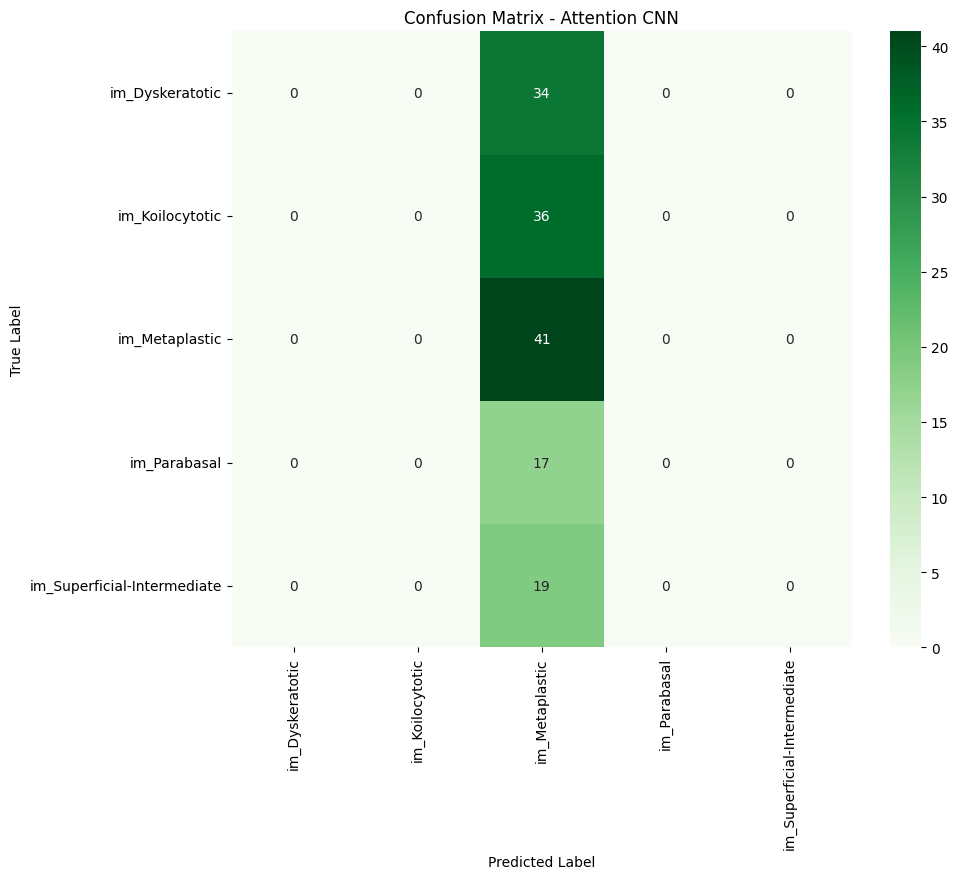

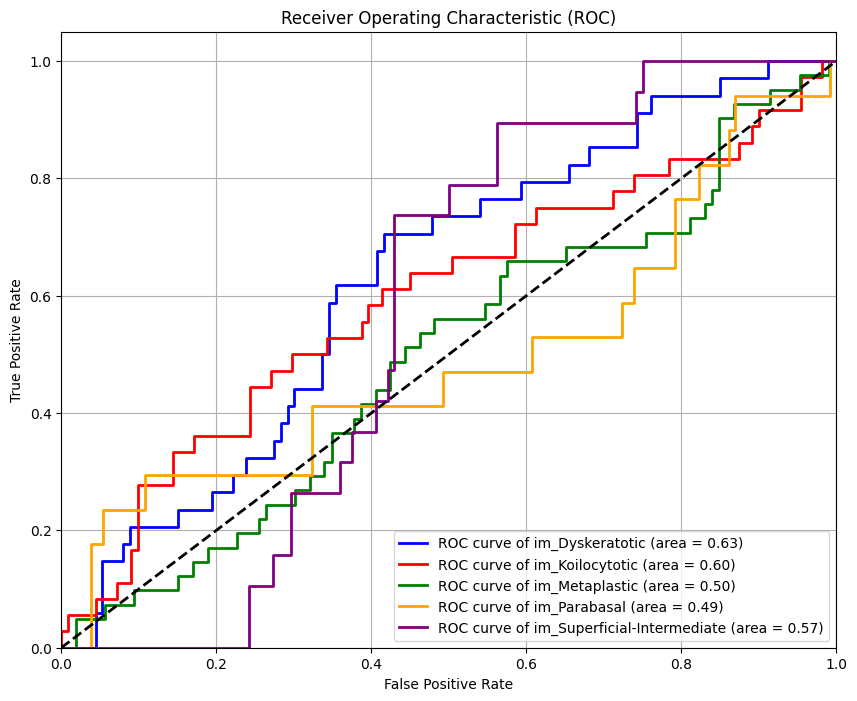

In [22]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# --- 1. GENERATE PREDICTIONS ---
print("\n--- Starting Evaluation ---")
start_test_time = time.time()

# Ensure we use the test_generator
test_generator.reset() 
y_pred_probs = att_model.predict(test_generator, verbose=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = test_generator.classes

end_test_time = time.time()
testing_duration = end_test_time - start_test_time

# Handle missing training_duration variable from previous error fixes
try:
    training_duration
except NameError:
    training_duration = 0 # Placeholder if time wasn't captured

# --- 2. PRINT METRICS ---
class_labels = list(test_generator.class_indices.keys())

print("-" * 50)
if training_duration > 0:
    print(f"Training Duration: {training_duration // 60:.0f}m {training_duration % 60:.0f}s")
else:
    print("Training Duration: Time not captured due to kernel restart.")
print(f"Testing Duration : {testing_duration:.2f} seconds")
print("-" * 50)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_labels))

# Overall Accuracy
overall_acc = accuracy_score(y_true_classes, y_pred_classes)
print(f"Overall Accuracy: {overall_acc:.4f}")

# --- 3. CONFUSION MATRIX ---
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Class-wise Accuracy
class_accuracies = cm.diagonal() / cm.sum(axis=1)
print("\nClass-wise Accuracy:")
for name, acc in zip(class_labels, class_accuracies):
    print(f"{name}: {acc:.4f}")

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Attention CNN')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# --- 4. ROC CURVE & AUC ---
# Binarize labels for One-vs-Rest ROC
y_true_bin = label_binarize(y_true_classes, classes=range(len(class_labels)))
n_classes = y_true_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC
plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_labels[i]} (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
